# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [4]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_cols=df.isnull().mean()
print(missing_cols)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['class','who','adult_male','deck','embark_town','alive','alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột alive gây target leakage (rò rỉ nhãn) vì nó chứa thông tin được xác định trực tiếp từ biến mục tiêu survived.Do đó, mô hình chỉ cần đọc giá trị của cột alive là biết ngay kết quả cần dự đoán, thay vì học mối quan hệ giữa các đặc trưng như age,sex,pclass,..

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [12]:
# TODO 2: shape, info, describe
print(df.shape,"\n") # biến mục tiêu là survived
print(df.info(),"\n")
print("Biến số(Numerical) là :","\n")
print(df.describe())
print("Biến phân loại(Categorical)  là :","\n")
print(df.describe(include="object"))

(891, 8) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None 

Biến số(Numerical) là : 

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      

**Trả lời 2 (biến số vs biến phân loại):**  
Bien so la : age, sibsp,parch, fare  
Bien phan loai(Categorical) la : survided, pclass(mac du la int64 nhung ban chat no la bien phan loai co thu tu (hang ve 1,2,3)), sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [13]:
# TODO 3: bảng missing (count + %)
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]
print(missing)

          Missing Count  Missing (%)
age                 177        19.87
embarked              2         0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|------|---------:|-------------------|--------|
| Age | 19.87% | Điền median | Biến số có thể có outlier nên median ổn định hơn mean. |
| Embarked | 0.22% | Điền mode | Biến phân loại, chỉ thiếu 2 giá trị. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [20]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s): #s(series) là col
    s=s.dropna() #loại bỏ các giá trị NaN
    Q1, Q3= s.quantile(0.25), s.quantile(0.75)
    IQR =Q3-Q1
    count_iqr =0
    for x in s:
        if x < Q1 -1.5*IQR or x> Q3+1.5*IQR: count_iqr+=1
    return count_iqr       # trả về số lượng outlier theo IQR

from scipy import stats

def dem_outlier_zscore(s, nguong=3.0):
    z_score=np.abs(stats.zscore(s.dropna())) 
    count_zscore= (z_score > nguong).sum()
    return count_zscore
    # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    print(f'Với cột {col} thì số outlier theo IQR là {dem_outlier_iqr(df[col])} và  theo Z-score là {dem_outlier_zscore(df[col])}')


Với cột age thì số outlier theo IQR là 11 và  theo Z-score là 2
Với cột fare thì số outlier theo IQR là 116 và  theo Z-score là 20


**Trả lời 4 (quyết định với outlier của `fare`):**  

Các outlier của cột `fare` được giữ lại vì chúng không phải lỗi dữ liệu mà phản ánh sự khác biệt về hạng vé (đặc biệt là vé hạng nhất có giá cao). Việc loại bỏ các giá trị này có thể làm mất thông tin quan trọng liên quan đến khả năng sống sót của hành khách. Chỉ loại bỏ những giá trị sai về mặt dữ liệu, ví dụ giá vé âm hoặc không hợp lệ.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

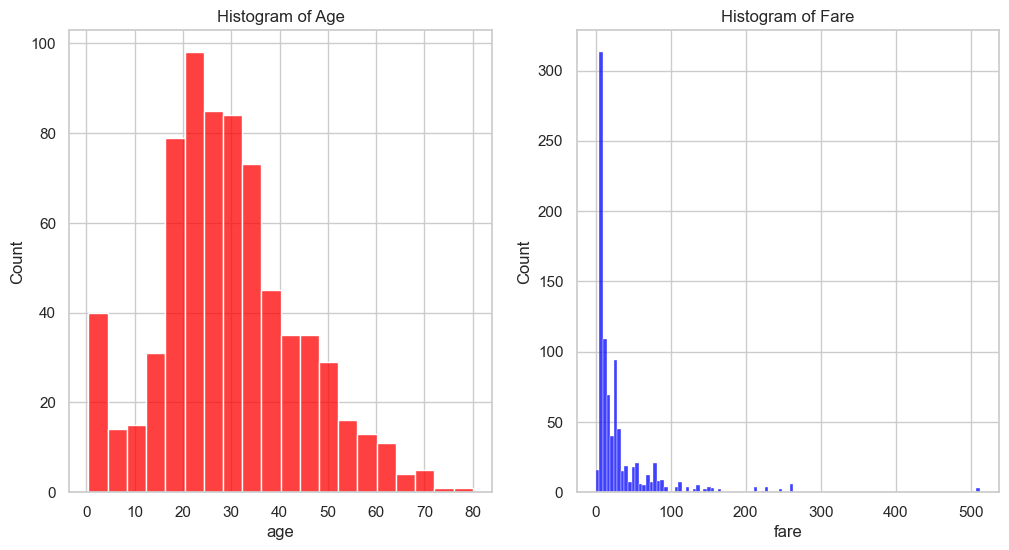

In [26]:
# TODO 5a: Histogram age & fare
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].set_title("Histogram of Age")
sns.histplot(data=df,x="age",ax=axes[0],color="red")
axes[1].set_title("Histogram of Fare")
sns.histplot(data=df,x="fare",ax=axes[1],color="blue")
plt.show()

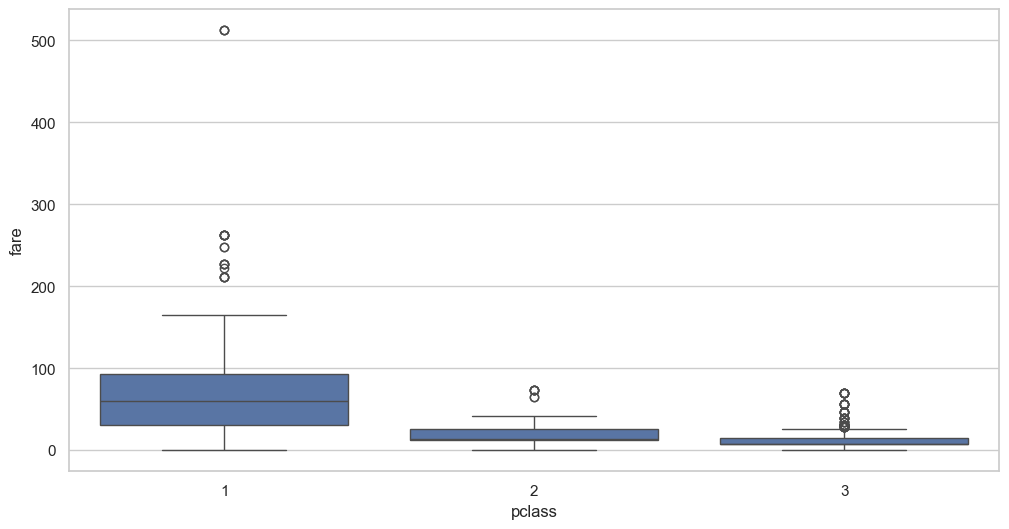

In [22]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig,zxc = plt.subplots(1,1,figsize=(12,6))
sns.boxplot(data=df,x="pclass",y="fare")
plt.show()

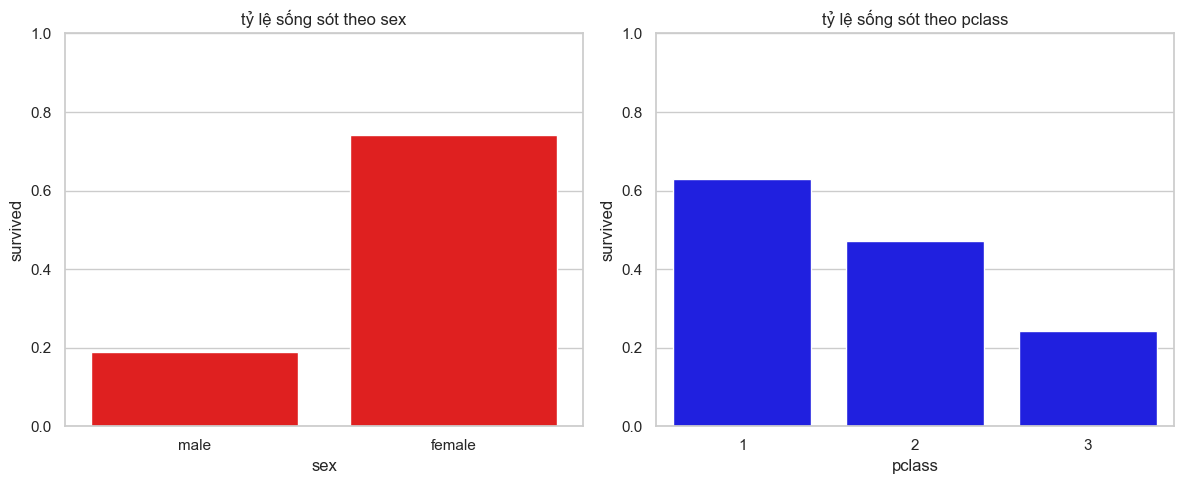

In [24]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x="sex", y="survived", ax=ax[0],color="red", errorbar=None)
ax[0].set_title("tỷ lệ sống sót theo sex")
ax[0].set_ylim(0, 1)
sns.barplot(data=df, x="pclass", y="survived", ax=ax[1],color="blue", errorbar=None)
ax[1].set_title("tỷ lệ sống sót theo pclass")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

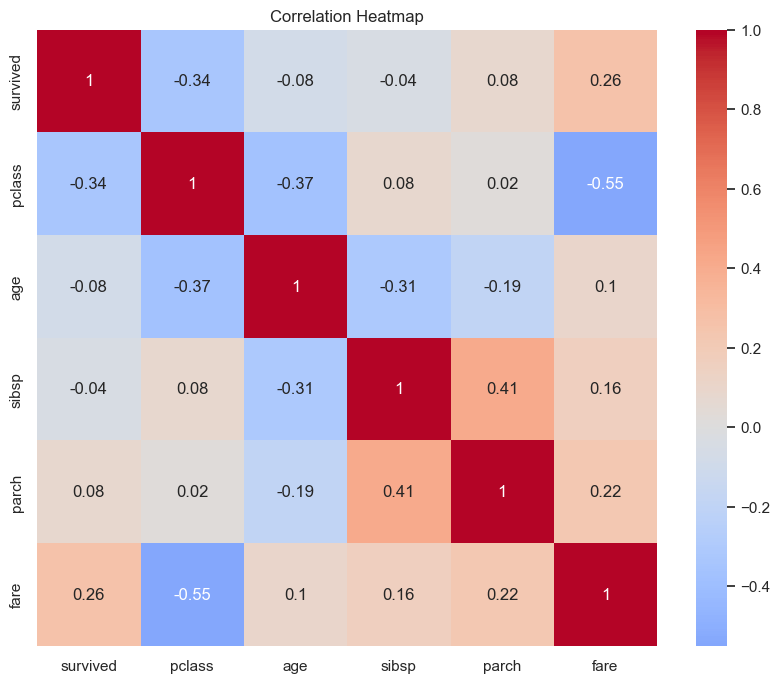

In [27]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True).round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram:   
  Age có phân phối lệch phải nhẹ, tập trung chủ yếu trong khoảng 20–35 tuổi.
  Số hành khách lớn tuổi (trên 60) và rất nhỏ tuổi tương đối ít.
  Fare có phân phối lệch phải rất mạnh, phần lớn hành khách trả mức vé thấp.
  Có một số giá vé rất cao, tạo đuôi dài và cho thấy khả năng tồn tại các giá trị ngoại lệ.
- Boxplot:    
  Hành khách hạng 1 (Pclass = 1) có giá vé trung vị cao nhất và xuất hiện nhiều outlier hơn hai hạng còn lại.
  Giá vé giảm dần từ hạng 1 -> hạng 2 -> hạng 3, đồng thời cả ba nhóm đều có một số giá trị ngoại lệ.
- Bar survival:  
Nữ có tỷ lệ sống sót cao hơn nam (khoảng 74% so với 19%).
Chênh lệch khoảng 55 điểm phần trăm, cho thấy giới tính ảnh hưởng rõ rệt đến khả năng sống sót.
Hành khách hạng 1 có tỷ lệ sống sót cao nhất (khoảng 63%), tiếp đến là hạng 2 (khoảng 47%) và thấp nhất là hạng 3 (khoảng 24%).
Điều này cho thấy hạng vé càng cao thì khả năng sống sót càng lớn.
- Heatmap:  
Cặp biến có tương quan mạnh nhất là Pclass và Fare (r ≈ -0.55), cho thấy hạng vé cao thường đi kèm giá vé cao.
Survived có tương quan âm với Pclass (r ≈ -0.34) và tương quan dương với Fare (r ≈ 0.26), còn các cặp biến khác chỉ tương quan yếu đến trung bình.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [29]:
# TODO 6: chia train/val/test có stratify
X = df.drop("survived",axis=1)
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y,test_size=0.15,random_state=42,stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp,test_size=15/85,random_state=42,stratify=y_tmp)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# in tỷ lệ survived từng tập
print("\nTỷ lệ survived:")
print(f"Train: {y_train.mean():.3f}")
print(f"Validation: {y_val.mean():.3f}")
print(f"Test: {y_test.mean():.3f}")


Train: (623, 7) (623,)
Validation: (134, 7) (134,)
Test: (134, 7) (134,)

Tỷ lệ survived:
Train: 0.384
Validation: 0.388
Test: 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [30]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train            
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Vì fit là bước học các thông tin từ dữ liệu (như median, giá trị phổ biến, hoặc các danh mục để mã hóa). Nếu fit trên toàn bộ dữ liệu (bao gồm validation hoặc test), thì quá trình tiền xử lý đã vô tình sử dụng thông tin từ những tập mà mô hình lẽ ra chưa được phép biet truoc.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [31]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df['survived'].value_counts(normalize=True).round(2))

survived
0    0.62
1    0.38
Name: proportion, dtype: float64


**Trả lời 8:**

1. Có,biến survived bị mất cân bằng nhẹ
Không sống sót (0): 549 người (61.6%)
Sống sót (1): 342 người (38.4%)
2. Có. Ví dụ nếu mô hình luôn dự đoán "không sống sót" thì Accuracy vẫn đạt khoảng 61.6%, mặc dù mô hình không phát hiện được bất kỳ người sống sót nào. Vì vậy Accuracy không phản ánh đầy đủ chất lượng mô hình khi dữ liệu mất cân bằng.
3. chon F1-score. Vì dữ liệu có mất cân bằng nhẹ nên F1-score cân bằng giữa Precision và Recall, giúp đánh giá mô hình toàn diện hơn Accuracy. Nếu chỉ dùng Accuracy có thể đánh giá quá cao một mô hình dự đoán thiên về lớp đa số. 

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Giới tính(sex) là đặc trưng ảnh hưởng mạnh nhất đến khả năng sống sót. Tỷ lệ sống của nữ cao hơn nam rất nhiều, thể hiện rõ trên biểu đồ tỷ lệ sống theo giới tính.
2. Cột age bị thiếu dữ liệu nhiều nhất(177 giá trị thiếu,khoảng 19.9%),xử lý bằng cách điền giá trị trung vị(median) trên tập train để giảm ảnh hưởng của ngoại lệ.
3. Biến mục tiêu (survived)hơi mất cân bằng (khoảng 61.6% không sống sót và 38.4% sống sót),vì vậy chỉ dùng Accuracy có thể gây hiểu nhầm. Nên kết hợp thêm Precision, Recall hoặcF1-score khi đánh giá mô hình.
4. Các biến số như age,fare,sibsp,parch cần scaling vì có đơn vị và khoảng giá trị khác nhau. Các biến phân loại như sex, embarked, pclass cần encoding để mô hình học được từ dữ liệu dạng số.
5. Một điểm thú vị là hành khách hạng vé cao(pclass = 1) và nữ giới có tỷ lệ sống sót cao hơn đáng kể so với nam giới hoặc hành khách hạng vé thấp

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [ ]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
